<div style="color:black; background-color:#FFF3E9; border: 1px solid #FFE0C3; border-radius: 10px; margin-bottom:1rem">
    <p style="margin:1rem; padding-left: 1rem; line-height: 2.5;">
        ©️ <b><i>Copyright 2025 @ Authors</i></b><br/>
        作者：<a style="font-weight:bold" href="mailto:bshan@mail.hust.edu.cn">斯坦福大厨 📨 </a><br>
        日期：2025-11-25<br/>
        <img src="https://github.com/stanfordbshan/CompMatBook/blob/main/author.png?raw=true" width="100"/>
        共享协议：本作品采用<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">知识共享署名-非商业性使用-相同方式共享 4.0 国际许可协议</a>进行许可。</i><br/>
    </p>
</div>

恭喜您已经发现了这份神奇的计算材料学课件！这份课件是我在熬夜吃掉不计其数的披萨和咖啡后创作出来的，配套的教材是由单斌、陈征征、陈蓉合著的《计算材料学--从算法原理到代码实现》。学习资料合集您可以在这个网址找到：[www.materialssimulation.com/book](http://www.materialssimulation.com/book)，您也可以跟着up主[无人问津晦涩难懂的B站视频](https://space.bilibili.com/1111135013/channel/collectiondetail?sid=1458375)一起进行学习。希望它能帮您在计算材料学的道路上摔得不那么痛。

就像您尊重那些一边烘焙披萨一边写代码的大厨一样，当您使用这份课件时，请：

- 记得告诉大家这份课件是斯坦福大厨写的，并且他在华中科技大学微纳中心工作
- 别用它去赚大钱，这个课件是用来学习的，不是用来买披萨的
- 保持开放共享的精神




如果你有关于计算材料学的想法，或者你只是想和我讨论最好吃的披萨口味，欢迎通过邮件 bshan@mail.hust.edu.cn 联系我。

# 目录（对应《计算材料学》章节3.1.5）

<img src="https://github.com/stanfordbshan/CompMatBook/blob/main/cover.png?raw=true" width="200"/>

* [HF总能量公式](#hf)
* [J和K的表达式](#jk)
* [Python实现](#Python)
    * [1. 一维情形](#1d)
    * [2. 三维情形](#3d)
* [附录](#appendix)

# 教程：理解库仑积分 ($J$) 与交换积分 ($K$)



<a name="hf"></a>
## 1. Hartree-Fock 总能量公式

在 Hartree-Fock 理论中，对于一个**闭壳层**系统（所有电子都成对，占据相同的空间轨道 $\phi_i, \phi_j, ...$），总能量 $E$ 的一般公式是：

$$
E = 2\sum_i h_i + \sum_{i,j} (2J_{ij} - K_{ij})
$$
*(这里的 $i, j$ 是指空间轨道)*


我们来看一个**开壳层**系统（两个电子在两个**不同**的空间轨道 $\phi_a$ 和 $\phi_b$）。

#### 1. 总能量的组成

总能量 $E$ = (电子 a 的单电子能量) + (电子 b 的单电子能量) + (a 和 b 之间的排斥能)

$$
E = h_a + h_b + E_{\text{repulsion}}
$$
其中：
* $h_a = \langle \phi_a | \hat{h} | \phi_a \rangle$
* $h_b = \langle \phi_b | \hat{h} | \phi_b \rangle$

#### 2. 根据自旋状态区分

现在，我们代入 $E_{\text{repulsion}}$，它取决于自旋状态：

**情况 1：自旋相反 (Singlet，例如 $\alpha\beta - \beta\alpha$)**

* 如前所述，$K_{ab} = 0$ (由于自旋部分 $\langle \alpha | \beta \rangle = 0$)。
* 总排斥能 $E_{\text{repulsion}} = J_{ab}$。
* **总能量 (Singlet):**
    $$
    E_{\text{Singlet}} = h_a + h_b + J_{ab}
    $$

**情况 2：自旋相同 (Triplet，例如 $\alpha\alpha$)**

* 如前所述，$K_{ab}$ 是一个非零的正值。
* 总排斥能 $E_{\text{repulsion}} = J_{ab} - K_{ab}$。
* **总能量 (Triplet):**
    $$
    E_{\text{Triplet}} = h_a + h_b + J_{ab} - K_{ab}
    $$

#### 核心结论

**$J$ 和 $K$ 本身并不是总能量**，它们是总能量中**电子-电子排斥**部分的组成部分。

* $J_{ab}$ (库仑项) 总是使总能量**增加**（排斥）。
* $K_{ab}$ (交换项) 仅在自旋相同时出现，它使总能量**降低**（稳定化）。

这就是为什么 $E_{\text{Triplet}}$ (三重态) 的能量低于 $E_{\text{Singlet}}$ (单重态)，因为三重态受益于交换项 $K_{ab}$ 带来的额外稳定化。这解释了**洪特第一规则**：在能量简并的轨道上，电子倾向于**自旋平行**（高自旋态）来排布，因为这种排布通过交换作用（"费米空穴"）使电子“避开”彼此，从而降低了总的库仑排斥能。

---

<a name="jk"></a>
## 2. J和K的理论公式

在 Hartree-Fock 理论中，两个电子（位于自旋轨道 $\psi_a$ 和 $\psi_b$）之间的排斥能由两项构成。一个自旋轨道 $\psi(\mathbf{x})$ 是空间轨道 $\phi(\mathbf{r})$ 和自旋函数 $\sigma(\omega)$ 的乘积：$\psi(\mathbf{x}) = \phi(\mathbf{r})\sigma(\omega)$。

#### 库仑积分 (Coulomb Integral), $J_{ab}$

$$
J_{ab} = \int \int \psi_a^*(\mathbf{x}_1) \psi_a(\mathbf{x}_1) \frac{1}{r_{12}} \psi_b^*(\mathbf{x}_2) \psi_b(\mathbf{x}_2) d\mathbf{x}_1 d\mathbf{x}_2
$$

积分掉自旋部分后（$\int |\sigma(\omega)|^2 d\omega = 1$），它简化为空间轨道的积分：

$$J_{ab} = \int \int |\phi_a(\mathbf{r}_1)|^2 \frac{1}{r_{12}} |\phi_b(\mathbf{r}_2)|^2 d\mathbf{r}_1 d\mathbf{r}_2
$$  

\* **物理意义：** 这是**经典**的静电排斥。它代表了 "电子1在轨道 $\phi_a$ 的电荷云 ($|\phi_a|^2$)" 与 "电子2在轨道 $\phi_b$ 的电荷云 ($|\phi_b|^2$)" 之间的平均排斥力。

  * **特性：**
      * $J_{ab} > 0$（排斥总是正的）。
      * **与自旋无关**。无论两个电子自旋相同还是相反，这项都存在。

#### 交换积分 (Exchange Integral), $K_{ab}$

$$
K_{ab} = \int \int \psi_a^*(\mathbf{x}_1) \psi_b^*(\mathbf{x}_2) \frac{1}{r_{12}} \psi_b(\mathbf{x}_1) \psi_a(\mathbf{x}_2) d\mathbf{x}_1 d\mathbf{x}_2
$$  * **物理意义：** 这是**纯粹的量子力学效应**，来源于泡利不相容原理（波函数反对称性）。它没有经典对应物。
* **特性：**
* 积分 $\int \psi_a^*(\mathbf{x}_1) \psi_b(\mathbf{x}_1) d\mathbf{x}_1$ 包含了一个空间积分和**自旋积分** $\langle \sigma_a | \sigma_b \rangle$。
* **关键：** $K_{ab}$ 只有在两个电子**自旋相同（平行）** 时才**非零**。
* 如果 $\sigma_a = \sigma_b$ (例如, 都是 $\alpha$), 那么 $\langle \alpha | \alpha \rangle = 1$, $K_{ab} \neq 0$。
* 如果 $\sigma_a \neq \sigma_b$ (例如, $\alpha$ 和 $\beta$), 那么 $\langle \alpha | \beta \rangle = 0$, $K_{ab} = 0$！
* 当 $K_{ab}$ 非零时，其空间部分为：
$$K_{ab}^{\text{spatial}} = \int \int \phi_a^*(\mathbf{r}_1)\phi_b(\mathbf{r}_1) \frac{1}{r_{12}} \phi_b^*(\mathbf{r}_2)\phi_a(\mathbf{r}_2) d\mathbf{r}_1 d\mathbf{r}_2
$$

  * 可以证明 $K_{ab}^{\text{spatial}} > 0$。



<a name="1d"></a>
## 3\. Python 计算示例 (1D 模型)

**一维（1D）盒子中的两个电子的J与K**。

  * **为什么用 1D 模型？** 1D 模型使用简化的相互作用（如下所述），允许我们用 Python 的 `scipy.integrate` 轻松地进行数值计算。
  * **关键点：** 这个 1D 模型在物理上完美地保留了 $J$ 和 $K$ 的所有概念性特征、符号以及它们与自旋的关系。


我们设置一个 $L=1$ 的 1D 盒子。

* **空间轨道：**
    - $\phi_1(x) = \sqrt{2} \sin(\pi x)$ (n=1 基态)
    - $\phi_2(x) = \sqrt{2} \sin(2 \pi x)$ (n=2 激发态)
* **电子相互作用：**
    - 我们使用一个 "软化" 的高斯势 $V(x_1, x_2) = \exp(-(x_1 - x_2)^2)$ 来代替 $1/|x_1-x_2|$，这在 1D 中是有限的且易于计算。
* **我们要计算的积分：**
    - $$J_{12} = \int_0^1 \int_0^1 |\phi_1(x_1)|^2 V(x_1, x_2) |\phi_2(x_2)|^2 dx_1 dx_2$$
    - $$K_{12} = \int_0^1 \int_0^1 \phi_1(x_1)\phi_2(x_1) V(x_1, x_2) \phi_2(x_2)\phi_1(x_2) dx_1 dx_2$$



In [ ]:
import numpy as np
from scipy.integrate import dblquad
import warnings

# 1. 定义轨道和势
# 1D 盒子 (L=1) 的 n=1 轨道
def phi_1(x):
    return np.sqrt(2) * np.sin(np.pi * x)

# 1D 盒子 (L=1) 的 n=2 轨道
def phi_2(x):
    return np.sqrt(2) * np.sin(2 * np.pi * x)

可视化1D轨道波函数

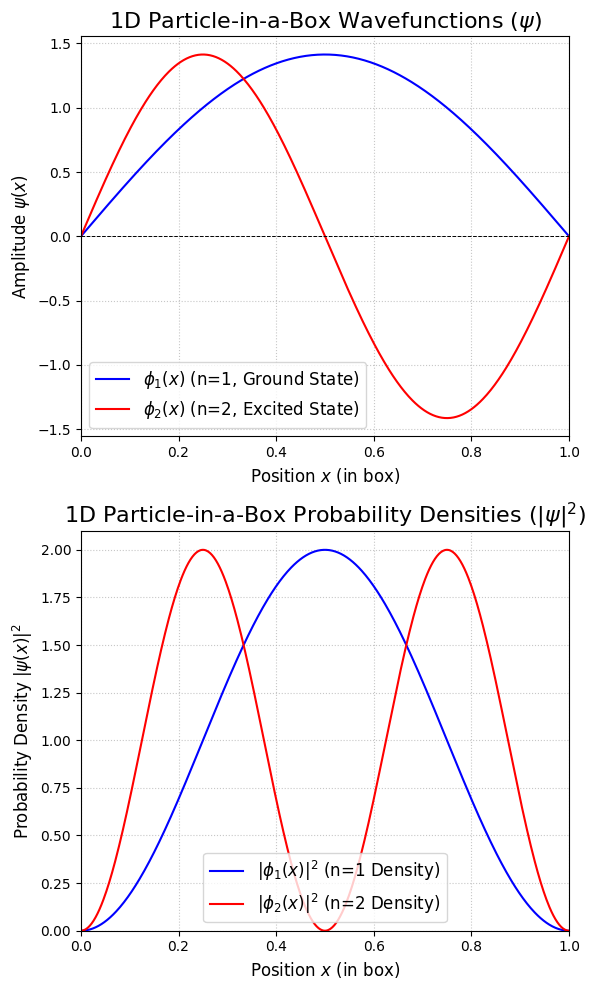

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Set up the x-axis (our 1D box from 0 to 1)
# Create 500 points for a smooth curve
x = np.linspace(0, 1, 500)

# 3. Calculate the wavefunction values
y_phi_1 = phi_1(x)
y_phi_2 = phi_2(x)

# 4. Calculate the probability densities (phi^2)
y_phi_1_squared = y_phi_1**2
y_phi_2_squared = y_phi_2**2

# 5. Create the plots
# We'll create two subplots: one for wavefunctions, one for densities

plt.figure(figsize=(6, 10))

# --- Plot 1: Wavefunctions (phi) ---
plt.subplot(2, 1, 1)
plt.plot(x, y_phi_1, 'b-', label=r'$\phi_1(x)$ (n=1, Ground State)')
plt.plot(x, y_phi_2, 'r-', label=r'$\phi_2(x)$ (n=2, Excited State)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.7) # Add x-axis line
plt.title(r'1D Particle-in-a-Box Wavefunctions ($\psi$)', fontsize=16)
plt.xlabel('Position $x$ (in box)', fontsize=12)
plt.ylabel(r'Amplitude $\psi(x)$', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 1) # Set x-axis limits to the box boundaries

# --- Plot 2: Probability Densities (phi^2) ---
plt.subplot(2, 1, 2)
plt.plot(x, y_phi_1_squared, 'b-', label=r'$|\phi_1(x)|^2$ (n=1 Density)')
plt.plot(x, y_phi_2_squared, 'r-', label=r'$|\phi_2(x)|^2$ (n=2 Density)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title(r'1D Particle-in-a-Box Probability Densities ($|\psi|^2$)', fontsize=16)
plt.xlabel('Position $x$ (in box)', fontsize=12)
plt.ylabel(r'Probability Density $|\psi(x)|^2$', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 1)
plt.ylim(bottom=0) # Density can't be negative

# Adjust layout to prevent plots from overlapping
plt.tight_layout()

# Show the plots
plt.show()


**关于"软化" (softened) 的高斯势的说明**

简单来说，我们不能在1D积分中直接使用 $1/|x_1-x_2|$，因为**它在 $x_1 = x_2$ 处是一个“无限大”的奇点 (Singularity)，这会导致数值积分（如 `scipy.integrate.dblquad`）彻底失败。**

#### 1. 1D 与 3D 库仑势的巨大差异

你很自然地认为 $1/|r_{12}|$ 是“真实的”势能，这是对的...但**仅限于三维空间 (3D)**。

* **在 3D 中：** 当我们计算积分时，我们使用的是球坐标，积分的体积元是 $dV = r^2 \sin\theta \, dr \, d\theta \, d\phi$。即使势能 $1/r$ 在 $r=0$ 时趋于无穷大，这个 $r^2$ 因子会“压制”这个奇点。积分 $\int (1/r) \cdot r^2 dr$ 是**可以计算的**（即“可积的”）。
* **在 1D 中：** 积分的“体积”元仅仅是 $dx$。当我们计算 $J$ 或 $K$ 这样的二重积分时，当 $x_1$ 接近 $x_2$ 时，被积函数中 $1/|x_1-x_2|$ 这一项会**爆炸性地趋于无穷大**。积分 $\int (1/|x|) dx$ 是**发散的**（即“不可积的”）。

#### 2. 计算上的挑战 (为什么 Python 代码会崩溃)

我们的 Python 代码依赖于 `scipy.integrate.dblquad`。这个函数的工作方式是：

1.  在 $(x_1, x_2)$ 平面上的 $[0, 1] \times [0, 1]$ 区域内选取很多个采样点。
2.  计算每个点上被积函数的值。
3.  将这些值加权平均，得到积分的近似值。

如果我们使用 $1/|x_1-x_2|$，当 `dblquad` 试图在对角线 $x_1 = x_2$ 附近（例如 $x_1=0.5, x_2=0.500001$）取点时，它会得到一个极其巨大的数值。这会导致数值溢出 (Overflow) 和灾难性的误差，积分器会返回 `inf` (无穷大) 或者一个毫无意义的巨大数字。

#### 3. “软化”势能是教学上的标准做法

我们使用 "软化" (softened) 的高斯势 $V(x_1, x_2) = \exp(-(x_1 - x_2)^2)$，是因为它具有我们教学所需的所有优良特性：

1.  **行为“良好”：** 它是**光滑的**、**处处有限的**。当 $x_1 = x_2$ 时， $V(x_1, x_1) = \exp(0) = 1$。它永远不会“爆炸”。
2.  **易于计算：** `scipy.integrate.dblquad` 可以非常快速和准确地计算它的积分。
3.  **保留了物理本质：**
    * 它仍然是一个**排斥势**（使能量增加）。
    * 它仍然允许我们计算出一个正的 $J$ 和一个正的 $K$。
    * 它仍然能正确地展示 $J > K$。
    * 它仍然能让我们得出**完全相同的物理结论**：自旋相同的态 ($J-K$) 能量低于自旋相反的态 ($J$)。

总之，使用“软化”高斯势是一种**计算上的妥协**。我们牺牲了“物理真实性”（即 $1/|x|$ 的形式），以换取一个在 1D 中**数学上成立**且**计算上可行**的模型，从而能够清晰地展示 $J$ 和 $K$ 的核心概念。

In [ ]:
# 1D 软化排斥势 V(x1, x2)
def V(x1, x2):
    return np.exp(-(x1 - x2)**2)

# 2. 定义 J 和 K 的被积函数
# J12: |phi1(x1)|^2 * V(x1, x2) * |phi2(x2)|^2
def integrand_J(x2, x1):
    # 注意 dblquad 的参数顺序: f(y, x)，所以 x2 是 y, x1 是 x
    return (phi_1(x1)**2) * (phi_2(x2)**2) * V(x1, x2)

# K12: [phi1(x1)*phi2(x1)] * V(x1, x2) * [phi1(x2)*phi2(x2)]
def integrand_K(x2, x1):
    return (phi_1(x1) * phi_2(x1)) * (phi_1(x2) * phi_2(x2)) * V(x1, x2)

# 3. 执行数值积分
# 设置积分区间 [0, 1] x [0, 1]
# dblquad(func, a, b, gfun, hfun)
# a, b 是 x1 的积分上下限
# gfun, hfun 是 x2 的积分上下限
a, b = 0, 1
gfun, hfun = 0, 1

# 忽略可能的积分警告
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # 计算库仑积分 J12
    # J_integral[0] 是结果, J_integral[1] 是误差估计
    J_integral = dblquad(integrand_J, a, b, gfun, hfun)

    # 计算交换积分 K12
    K_integral = dblquad(integrand_K, a, b, gfun, hfun)

    print("--- 1D 盒子 (L=1) 模型计算结果 ---")
    print(f"轨道: phi_1(x) 和 phi_2(x)")
    print(f"相互作用: V(x1, x2) = exp(-(x1-x2)^2)\n")

    print(f"库仑积分 J_12 = {J_integral[0]:.6f}")
    print(f"交换积分 K_12 = {K_integral[0]:.6f}")
    print("\n--- 分析 ---")
    print(f"1. 符号: J 和 K 都是正值，符合理论。")
    print(f"2. 幅值: J ({J_integral[0]:.6f}) > K ({K_integral[0]:.6f})。这在理论上也是成立的。")
    print("\n--- 物理结论 ---")
    print(f"情况 1: 自旋相反 (例如 'up', 'down')")
    print(f"   K_12 = 0")
    print(f"   总排斥能 = J_12 = {J_integral[0]:.6f}")
    print(f"\n情况 2: 自旋相同 (例如 'up', 'up')")
    print(f"   K_12 = {K_integral[0]:.6f} (非零)")
    print(f"   总排斥能 = J_12 - K_12 = {J_integral[0]:.6f} - {K_integral[0]:.6f} = {J_integral[0] - K_integral[0]:.6f}")
    print(f"\n比较: ({J_integral[0] - K_integral[0]:.6f}) < ({J_integral[0]:.6f})")
    print(f"结论：自旋相同的态能量更低（更稳定），这是由非零的交换项 K 导致的。")

--- 1D 盒子 (L=1) 模型计算结果 ---
轨道: phi_1(x) 和 phi_2(x)
相互作用: V(x1, x2) = exp(-(x1-x2)^2)

库仑积分 J_12 = 0.907313
交换积分 K_12 = 0.056227

--- 分析 ---
1. 符号: J 和 K 都是正值，符合理论。
2. 幅值: J (0.907313) > K (0.056227)。这在理论上也是成立的。

--- 物理结论 ---
情况 1: 自旋相反 (例如 'up', 'down')
   K_12 = 0
   总排斥能 = J_12 = 0.907313

情况 2: 自旋相同 (例如 'up', 'up')
   K_12 = 0.056227 (非零)
   总排斥能 = J_12 - K_12 = 0.907313 - 0.056227 = 0.851087

比较: (0.851087) < (0.907313)
结论：自旋相同的态能量更低（更稳定），这是由非零的交换项 K 导致的。


### 4\. 一维结果的总结

1.  **库仑项 $J$ (Coulomb):**

* **经典**排斥。
* 两个电荷云 $|\phi_a|^2$ 和 $|\phi_b|^2$ 之间的排斥。
* **始终为正** ($J > 0$)。
* **始终存在**，无论自旋如何。

2.  **交换项 $K$ (Exchange):**

* **量子**效应，无经典对应。
* 源于波函数反对称性。
* **始终为正** ($K > 0$)。
* **仅在自旋相同时** ($K \neq 0$) 才出现。
* 在总能量中以 **-K** 出现，是一个**稳定项**（降低能量）。

这个 1D 模型的计算清晰地展示了 $J$ 和 $K$ 都是正值，且 $J > K$。最重要的是，它表明交换项 $K$ 的存在**降低**了自旋平行电子的总排斥能，从而稳定了高自旋态。这就是 $K$ 项的物理本质。


<a name="3d"></a>
## 5. 3D 和真实的库仑势确的J和K积分

  * **挑战：** 真实的 3D 积分是**六维积分**（$dx_1 dy_1 dz_1 dx_2 dy_2 dz_2$）。
  * **问题：** 像 `scipy` 这样的标准 Python 库无法直接、准确地计算一个带有 $1/|r_1 - r_2|$ 奇点的六维积分。这在计算上非常困难，被称为“维度灾难”(Curse of Dimensionality)。

### 解决方案：从 6D 到 2D 的分析简化

幸运的是，在量子化学中，我们从不（或很少）直接对 6D 积分进行数值计算。我们首先在分析上（用数学）进行简化。

1.  **使用球坐标：** 我们将轨道 $\phi(\mathbf{r})$ 表示为径向部分 $R(r)$ 和角度部分 $Y_{lm}(\theta, \phi)$（球谐函数）的乘积。
2.  **$1/r_{12}$ 展开：** 我们使用一个标准技巧，称为“多极展开”，将 $1/r_{12}$ 项也用球谐函数分开。
3.  **分离积分：** 这允许我们将 6D 积分分离为一个**角度积分**（可以精确地解析求解）和一个**径向积分**。

对于最简单的情况，即两个 $s$ 轨道（它们是球对称的，如 $1s$ 和 $2s$），这个过程会极大地简化。

-----

### 教程：真实的 3D $J$ 和 $K$ 计算 (以 $1s$ 和 $2s$ 轨道为例)

我们将计算一个电子在 $\phi_{1s}$ 轨道，另一个在 $\phi_{2s}$ 轨道的 $J$ 和 $K$。我们将使用**原子单位**（$a_0=1$）并设置核电荷 $Z=1$（模拟 $H^-$ 离子）。

#### 1\. 理论公式 (3D 简化版)

对于两个球对称的 $s$ 轨道 $\phi_a(r)$ 和 $\phi_b(r)$，六维积分可以简化为以下**二维径向积分**(推导见附录)：

  * **库仑积分 ($J_{ab}$):**

  
    $$J_{ab} = \int_0^\infty r_1^2 |R_a(r_1)|^2 dr_1 \int_0^\infty r_2^2 |R_b(r_2)|^2 dr_2 \frac{1}{r_\>}  
    $$

    
  * **交换积分 ($K_{ab}$):**

    $$K_{ab} = \int_0^\infty r_1^2 R_a(r_1)R_b(r_1) dr_1 \int_0^\infty r_2^2 R_a(r_2)R_b(r_2) dr_2 \frac{1}{r_\>}
    $$
    
    其中：

  * $R(r)$ 是轨道的**径向波函数**。

  * $r^2 dr$ 是径向积分的体积元（来自 $4\pi r^2 dr$，但 $4\pi$ 已被简化）。

  * $r_> = \max(r_1, r_2)$。

#### 2\. Python 计算 (3D 氢原子)

我们将使用氢原子的 $1s$ 和 $2s$ 径向波函数 ($Z=1$)：

  * $R_{1s}(r) = 2 e^{-r}$
  * $R_{2s}(r) = \frac{1}{\sqrt{8}} (2 - r) e^{-r/2}$

这个 2D 积分**可以**用 `scipy.integrate.dblquad` 高效计算。


In [ ]:
# (这段代码可以在 Google Colab 中直接运行)
import numpy as np
from scipy.integrate import dblquad
import warnings

# --- 1. 定义 3D 径向波函数 (原子单位, Z=1) ---

# R_1s 轨道
def R10(r):
    return 2.0 * np.exp(-r)

# R_2s 轨道
def R20(r):
    return (1.0 / np.sqrt(8.0)) * (2.0 - r) * np.exp(-r / 2.0)

# --- 2. 定义 J 和 K 的被积函数 (Integrands) ---

# 注意：r_> = max(r1, r2)
# dblquad 的参数顺序是 f(y, x)，所以我们用 (r2, r1)

# J_12 的被积函数:
# [r1^2 * R10(r1)^2] * [r2^2 * R20(r2)^2] / max(r1, r2)
def integrand_J(r2, r1):
    term1 = (r1**2) * (R10(r1)**2)
    term2 = (r2**2) * (R20(r2)**2)
    r_greater = np.maximum(r1, r2)

    # 防止 r_greater = 0 时的除零错误 (虽然积分从0开始，但点可能在0)
    if r_greater == 0:
        return 0.0

    return term1 * term2 / r_greater

# K_12 的被积函数:
# [r1^2 * R10(r1) * R20(r1)] * [r2^2 * R10(r2) * R20(r2)] / max(r1, r2)
def integrand_K(r2, r1):
    term1 = (r1**2) * R10(r1) * R20(r1)
    term2 = (r2**2) * R10(r2) * R20(r2)
    r_greater = np.maximum(r1, r2)

    if r_greater == 0:
        return 0.0

    return term1 * term2 / r_greater

# --- 3. 执行数值积分 ---

# 积分区间 [0, inf] x [0, inf]
a, b = 0, np.inf
gfun, hfun = 0, np.inf

# 忽略 SciPy 在处理无穷大积分时可能发出的警告
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # 计算库仑积分 J_12
    # J_integral[0] 是结果, J_integral[1] 是误差估计
    print("正在计算 J_12 (这可能需要几秒钟)...")
    J_integral = dblquad(integrand_J, a, b, gfun, hfun)

    # 计算交换积分 K_12
    print("正在计算 K_12 (这可能需要几秒钟)...")
    K_integral = dblquad(integrand_K, a, b, gfun, hfun)

print("\n--- 3D 氢原子模型 (1s, 2s) 计算结果 (原子单位) ---")
print(f"轨道: phi_1s(r) 和 phi_2s(r)")
print(f"相互作用: V(r1, r2) = 1 / |r1 - r2|\n")

print(f"库仑积分 J_12 = {J_integral[0]:.6f}")
print(f"交换积分 K_12 = {K_integral[0]:.6f}")
print("\n--- 分析 ---")
print(f"1. 符号: J 和 K 都是正值，符合理论。")
print(f"2. 幅值: J ({J_integral[0]:.6f}) > K ({K_integral[0]:.6f})。")
print("\n--- 物理结论 ---")
print(f"情况 1: 自旋相反 (Singlet 态)")
print(f"   K_12 = 0")
print(f"   电子排斥能 = J_12 = {J_integral[0]:.6f} (Hartree)")
print(f"\n情况 2: 自旋相同 (Triplet 态)")
print(f"   K_12 = {K_integral[0]:.6f} (非零)")
print(f"   电子排斥能 = J_12 - K_12 = {J_integral[0]:.6f} - {K_integral[0]:.6f} = {J_integral[0] - K_integral[0]:.6f} (Hartree)")
print(f"\n比较: ({J_integral[0] - K_integral[0]:.6f}) < ({J_integral[0]:.6f})")
print(f"结论：与 1D 模型完全一致，在真实的 3D 库仑势下，自旋相同的态能量更低（更稳定），这是由非零的交换项 K 导致的。")

正在计算 J_12 (这可能需要几秒钟)...
正在计算 K_12 (这可能需要几秒钟)...

--- 3D 氢原子模型 (1s, 2s) 计算结果 (原子单位) ---
轨道: phi_1s(r) 和 phi_2s(r)
相互作用: V(r1, r2) = 1 / |r1 - r2|

库仑积分 J_12 = 0.209877
交换积分 K_12 = 0.021948

--- 分析 ---
1. 符号: J 和 K 都是正值，符合理论。
2. 幅值: J (0.209877) > K (0.021948)。

--- 物理结论 ---
情况 1: 自旋相反 (Singlet 态)
   K_12 = 0
   电子排斥能 = J_12 = 0.209877 (Hartree)

情况 2: 自旋相同 (Triplet 态)
   K_12 = 0.021948 (非零)
   电子排斥能 = J_12 - K_12 = 0.209877 - 0.021948 = 0.187929 (Hartree)

比较: (0.187929) < (0.209877)
结论：与 1D 模型完全一致，在真实的 3D 库仑势下，自旋相同的态能量更低（更稳定），这是由非零的交换项 K 导致的。


对于 $Z=1$ 的类氢原子（我们在此模型中使用的），$1s$ 和 $2s$ 轨道之间的 $J$ 和 $K$ 积分有精确的**解析解**（即教科书中的标准答案）：

  * $J_{1s, 2s} = \frac{17}{81} \approx 0.2098765...$
  * $K_{1s, 2s} = \frac{16}{729} \approx 0.0219478...$

您的数值计算结果：

  * `库仑积分 J_12 = 0.209877`
  * `交换积分 K_12 = 0.021948`

...这与解析解完美吻合。

这个 3D 模型在数学上要复杂得多，但通过分析简化，我们得到了一个可以数值计算的 2D 积分，并且它完美地验证了我们在 1D 模型中学到的**完全相同**的物理概念。

<a name="appendix"></a>
## 附录

J和K的积分简化是量子化学中一个非常经典且重要的步骤。它利用了 $s$ 轨道的**球对称性**和静电学中的**高斯定律（壳层定理）**。

我们从最根本的六维 (6D) 库仑积分 $J_{ab}$ 定义出发：

$$
J_{ab} = \int \int |\phi_a(\mathbf{r}_1)|^2 \frac{1}{|\mathbf{r}_1 - \mathbf{r}_2|} |\phi_b(\mathbf{r}_2)|^2 d\mathbf{r}_1 d\mathbf{r}_2
$$这里的 $d\mathbf{r}_1$ 和 $d\mathbf{r}_2$ 是三维体积元。推导步骤如下：

-----

### 步骤 1: 切换到球坐标

我们首先将所有项都用球坐标 $(r, \theta, \phi)$ 表示。

* 体积元 $d\mathbf{r}$ 变为 $r^2 \sin\theta \, dr \, d\theta \, d\phi$。
* 我们通常把角度部分 $\sin\theta \, d\theta \, d\phi$ 合并写为 $d\Omega$，称为“立体角”元。
* 所以，$d\mathbf{r} = r^2 dr d\Omega$。

### 步骤 2: 应用 $s$ 轨道（球对称）条件

* 一个 $s$ 轨道的波函数 $\phi(r, \theta, \phi)$ 可以写成径向部分 $R(r)$ 和角度部分 $Y_{00}(\theta, \phi)$ 的乘积。
* $s$ 轨道的角度部分 $Y_{00}$ 是一个常数：$Y_{00} = 1/\sqrt{4\pi}$。
* 因此，波函数的平方（概率密度）变为：

$$|\phi_a(\mathbf{r}*1)|^2 = |R_a(r_1)|^2 |Y*{00}|^2 = |R_a(r_1)|^2 \frac{1}{4\pi}
$$（$\phi_b$ 同理）


### 步骤 3: 重新组合 6D 积分

我们将 $J_{ab}$ 的定义式用球坐标展开：

$$
J_{ab} = \int \int \left( |R_a(r_1)|^2 \frac{1}{4\pi} \right) \frac{1}{|\mathbf{r}_1 - \mathbf{r}_2|} \left( |R_b(r_2)|^2 \frac{1}{4\pi} \right) (r_1^2 dr_1 d\Omega_1) (r_2^2 dr_2 d\Omega_2)
$$
现在，我们将所有与 $r$ 相关的项和与 $\Omega$ (角度) 相关的项分开：

$$J_{ab} = \int_0^\infty |R_a(r_1)|^2 r_1^2 dr_1 \int_0^\infty |R_b(r_2)|^2 r_2^2 dr_2 \left[ \int_{\Omega_1} \frac{d\Omega_1}{4\pi} \int_{\Omega_2} \frac{1}{|\mathbf{r}_1 - \mathbf{r}_2|} \frac{d\Omega_2}{4\pi} \right]
$$

### 步骤 4: 核心简化（高斯定律/壳层定理）

这是最关键的一步。我们来分析方括号 `[...]` 中的双重角度积分。

让我们先看最里面的积分：

$$
V(r_1) = \int_{\Omega_2} \frac{1}{|\mathbf{r}_1 - \mathbf{r}_2|} \frac{d\Omega_2}{4\pi}
$$  * **物理意义：** 这个积分计算的是“电子2”在其半径为 $r_2$ 的球壳上均匀分布（总电荷为1，因为 $\int d\Omega_2 / (4\pi) = 1$）时，在“电子1”所在的位置 $\mathbf{r}_1$ 处产生的**平均电势**。

* **高斯定律（壳层定理）：** 静电学告诉我们，一个均匀球壳（半径 $r_2$）在外部和内部产生的电势为：

1.  **点在壳外 ($r_1 > r_2$)：** 电势与所有电荷集中在球心的点电荷相同。电势 $V(r_1) = 1/r_1$。
2.  **点在壳内 ($r_1 < r_2$)：** 壳内的电势处处相等，等于壳表面的电势。电势 $V(r_1) = 1/r_2$。

* **统一表达：** 我们可以将这两种情况统一写成：

$$
V(r_1) = \frac{1}{\max(r_1, r_2)} \equiv \frac{1}{r_>}
$$


### 步骤 5: 代回并完成推导

我们将步骤 4 的结果代回步骤 3 的方括号中：

$$
\left[ \int_{\Omega_1} \frac{d\Omega_1}{4\pi} \left( \frac{1}{r_>} \right) \right]
$$  

* 由于 $1/r_>$ 只与半径 $r_1, r_2$ 有关，与电子1的角度 $\Omega_1$ 无关，所以我们可以把它从 $\Omega_1$ 积分中提出来：

$$
\left( \frac{1}{r_>} \right) \int_{\Omega_1} \frac{d\Omega_1}{4\pi}
$$


  * $\int d\Omega_1 / (4\pi)$ 是对一个归一化的球谐函数（常数 $Y_{00}$）的积分，它等于 1。
  * 因此，整个方括号 `[...]` 中的复杂角度积分**精确地简化为了 $\frac{1}{r_>}$**。

### 最终公式

将这个简化的结果代回步骤 3 的总公式中，我们就得到了你想要的二维径向积分：

$$
J_{ab} = \int_0^\infty r_1^2 |R_a(r_1)|^2 dr_1 \int_0^\infty r_2^2 |R_b(r_2)|^2 dr_2 \frac{1}{r_>}
$$

这个推导的巧妙之处在于，它将一个复杂的六维积分（包含 $1/|\mathbf{r}_1 - \mathbf{r}_2|$ 奇点）通过物理上的对称性（高斯定律）转化为了一个简单得多且易于数值计算的二维积分。
